# 02 — Exploratory Data Analysis

This notebook explores the joined click dataset to find patterns that may help predict clicks.

## Install required packages

In [1]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid")

current_dir = Path.cwd().resolve()
project_root = next(
    (path for path in [current_dir, *current_dir.parents] if (path / "data" / "interim").exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find data/interim. Start Jupyter inside this project.")

joined_path = project_root / "data" / "interim" / "click_data_joined.csv"
print(f"Reading: {joined_path}")

Reading: /Users/namees.local/Desktop/ensamble_technique/data/interim/click_data_joined.csv


## Load and check the joined data

In [3]:
df = pd.read_csv(joined_path, parse_dates=["event_ts"])
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())
display(pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=True),
}))

Rows: 450,000
Columns: 22


,impression_id,user_id,product_id,event_ts,platform,device_os,page_type,slot_position,hour_of_day,day_of_week,clicked,product_name,brand,category,price_usd,discount_pct,avg_rating,review_count,age,gender,city,loyalty_tier
0,1,6166,838,2026-03-01 17:51:00,mobile_app,iOS,product_detail,1,6,Thu,0,KitchenAid Compact Cordless Vacuum,KitchenAid,Home,602.950,7,4.200,385,41,F,Philadelphia,Silver
1,2,840,807,2026-01-07 07:35:00,mobile_app,Android,search,1,19,Wed,0,Dyson Everyday Bedding Set,Dyson,Home,109.990,1,3.700,62,31,F,Dallas,Platinum
2,3,7780,884,2026-04-22 06:44:00,mobile_app,iOS,category,2,0,Sun,0,The Golden Signal - Workbook,Simon & Schuster,Books,12.990,5,3.500,273,39,M,Long Tail,Gold
3,4,4422,307,2026-04-29 23:10:00,website,Web,search,1,14,Sat,0,Apple Tablet Plus,Apple,Electronics,174.990,2,4.400,94,43,M,Philadelphia,Gold
4,5,3620,804,2026-04-25 19:45:00,website,Web,product_detail,1,4,Mon,0,Nike Heritage Graphic Tee,Nike,Fashion,38.950,7,4.000,62,32,F,Charlotte,Silver


,dtype,missing,unique
impression_id,int64,0,450000
user_id,int64,0,8000
product_id,int64,0,1200
event_ts,datetime64[us],0,213195
platform,str,0,2
device_os,str,0,3
page_type,str,0,4
slot_position,int64,0,6
hour_of_day,int64,0,24
day_of_week,str,0,7


## Click target balance

,rows,percent
clicked,,
0,419013,93.114
1,30987,6.886


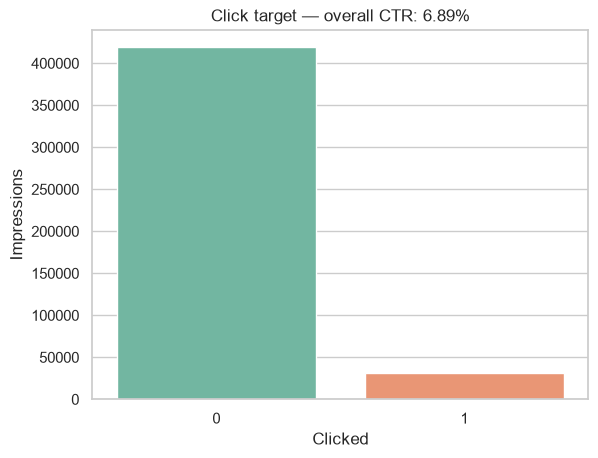

In [4]:
target_summary = df["clicked"].value_counts().sort_index().to_frame("rows")
target_summary["percent"] = 100 * target_summary["rows"] / len(df)
display(target_summary)

ax = sns.countplot(data=df, x="clicked", hue="clicked", palette="Set2", legend=False)
ax.set(title=f"Click target — overall CTR: {df['clicked'].mean():.2%}", xlabel="Clicked", ylabel="Impressions")
plt.show()

## Click rate by browsing context

### platform

,impressions,clicks,click_rate
platform,,,
website,103244,7534,0.073
mobile_app,346756,23453,0.068


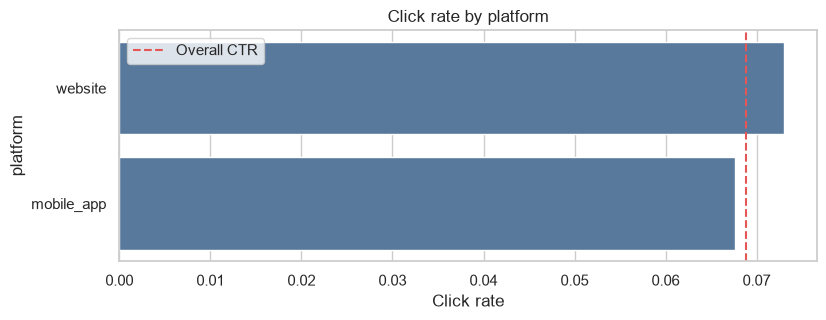

### device_os

,impressions,clicks,click_rate
device_os,,,
Web,103244,7534,0.073
Android,152192,10295,0.068
iOS,194564,13158,0.068


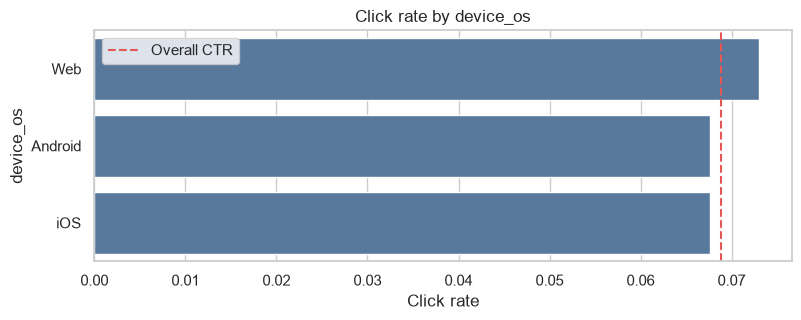

### page_type

,impressions,clicks,click_rate
page_type,,,
product_detail,99008,8312,0.084
search,81151,5716,0.070
category,121508,7858,0.065
home,148333,9101,0.061


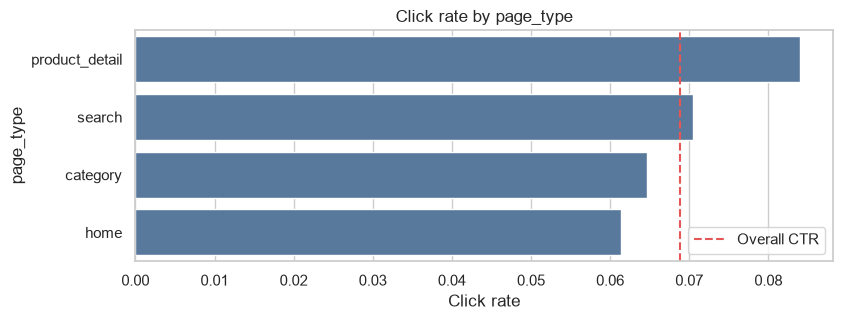

### slot_position

,impressions,clicks,click_rate
slot_position,,,
1,134974,13067,0.097
2,108059,8273,0.077
3,81313,4545,0.056
4,58191,2765,0.048
5,40344,1419,0.035
6,27119,918,0.034


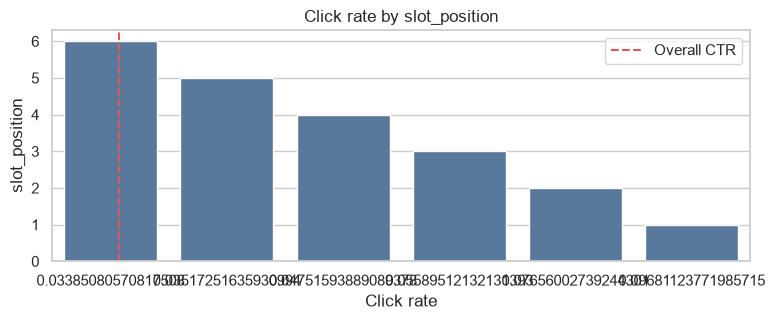

### day_of_week

,impressions,clicks,click_rate
day_of_week,,,
Sun,62894,4494,0.071
Sat,67703,4674,0.069
Wed,63200,4356,0.069
Fri,67614,4633,0.069
Thu,63132,4322,0.068
Tue,62717,4276,0.068
Mon,62740,4232,0.067


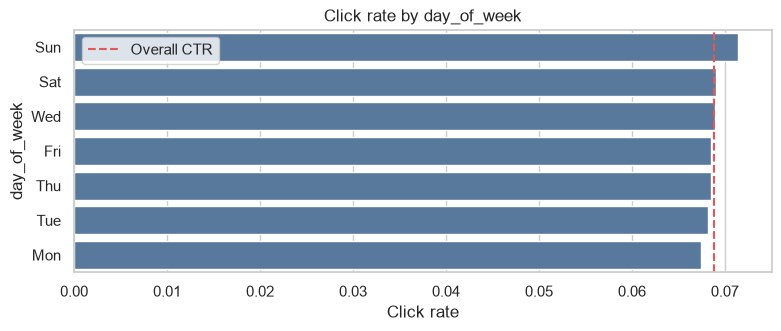

In [5]:
def plot_group_ctr(data, column, min_rows=1):
    summary = (
        data.groupby(column, dropna=False)["clicked"]
        .agg(impressions="size", clicks="sum", click_rate="mean")
        .query("impressions >= @min_rows")
        .sort_values("click_rate", ascending=False)
    )
    display(summary)
    plt.figure(figsize=(9, max(3, 0.45 * len(summary))))
    sns.barplot(data=summary.reset_index(), y=column, x="click_rate", color="#4C78A8")
    plt.axvline(data["clicked"].mean(), color="#E45756", linestyle="--", label="Overall CTR")
    plt.title(f"Click rate by {column}")
    plt.xlabel("Click rate")
    plt.legend()
    plt.show()
    return summary

context_summaries = {}
for column in ["platform", "device_os", "page_type", "slot_position", "day_of_week"]:
    display(Markdown(f"### {column}"))
    context_summaries[column] = plot_group_ctr(df, column)

## Click patterns by hour

,hour_of_day,impressions,click_rate
0,0,18944,0.063
1,1,18661,0.065
2,2,18760,0.063
3,3,18917,0.062
4,4,18801,0.064
5,5,18797,0.064
6,6,18765,0.069
7,7,18627,0.066
8,8,18765,0.068
9,9,18693,0.072


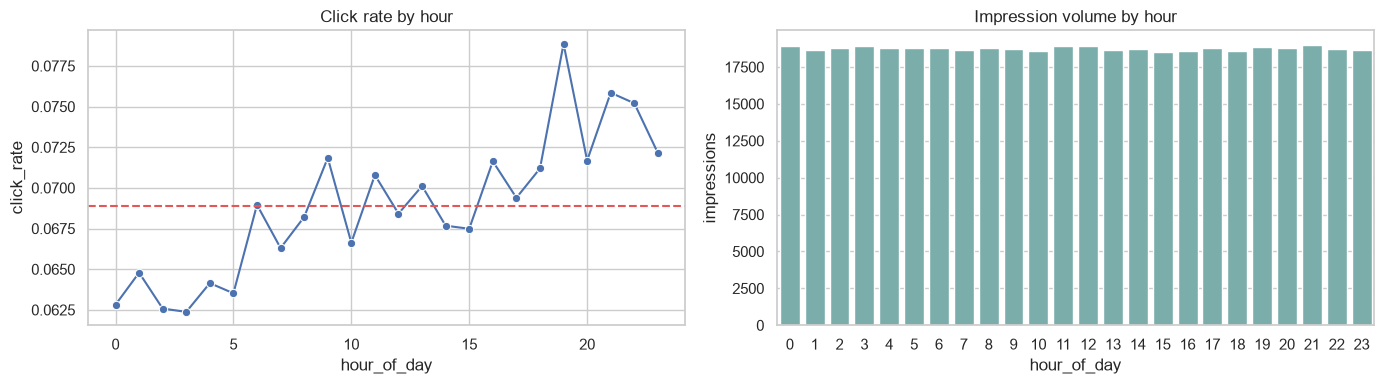

In [6]:
hourly = df.groupby("hour_of_day")["clicked"].agg(impressions="size", click_rate="mean").reset_index()
display(hourly)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=hourly, x="hour_of_day", y="click_rate", marker="o", ax=axes[0])
axes[0].axhline(df["clicked"].mean(), color="#E45756", linestyle="--")
axes[0].set_title("Click rate by hour")
sns.barplot(data=hourly, x="hour_of_day", y="impressions", color="#72B7B2", ax=axes[1])
axes[1].set_title("Impression volume by hour")
plt.tight_layout()
plt.show()

## User and product segments

### gender

,impressions,clicks,click_rate
gender,,,
M,224100,15953,0.071
F,217561,14531,0.067
Other,8339,503,0.060


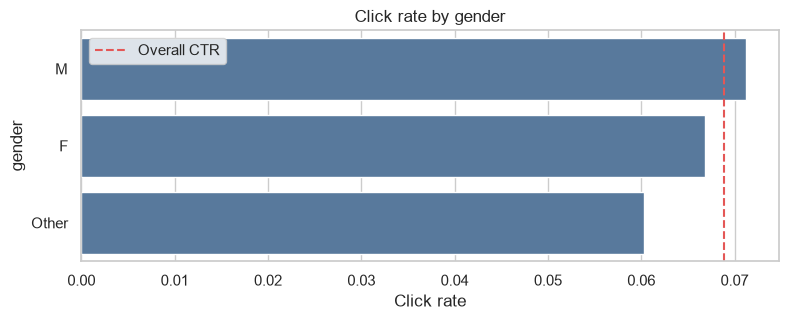

### loyalty_tier

,impressions,clicks,click_rate
loyalty_tier,,,
Platinum,49396,3841,0.078
Gold,123967,8905,0.072
Silver,231146,15303,0.066
Bronze,45491,2938,0.065


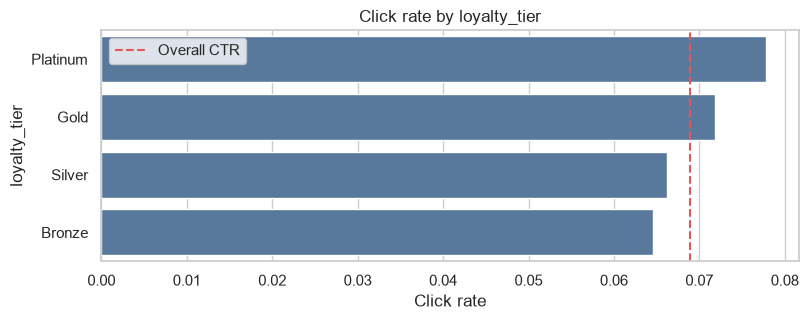

### category

,impressions,clicks,click_rate
category,,,
Fashion,62457,7404,0.119
Electronics,78310,8721,0.111
Grocery,70379,6567,0.093
Home,56446,3064,0.054
Sports,51230,1921,0.037
Beauty,50912,1874,0.037
Books,43179,828,0.019
Toys,37087,608,0.016


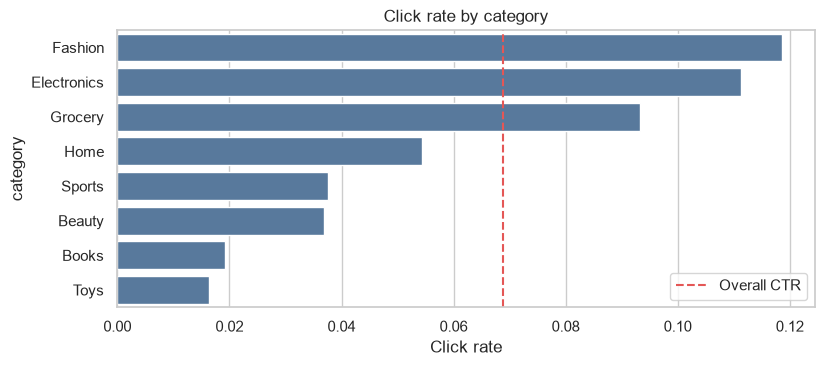

### brand

,impressions,clicks,click_rate
brand,,,
Samsung,24661,3271,0.133
Apple,14691,1917,0.130
Calvin Klein,14016,1735,0.124
Levi's,12694,1507,0.119
Tommy Hilfiger,10900,1269,0.116
Kraft Heinz,12965,1451,0.112
General Mills,11828,1237,0.105
Sony,26904,2797,0.104
Kellogg's,14785,1399,0.095


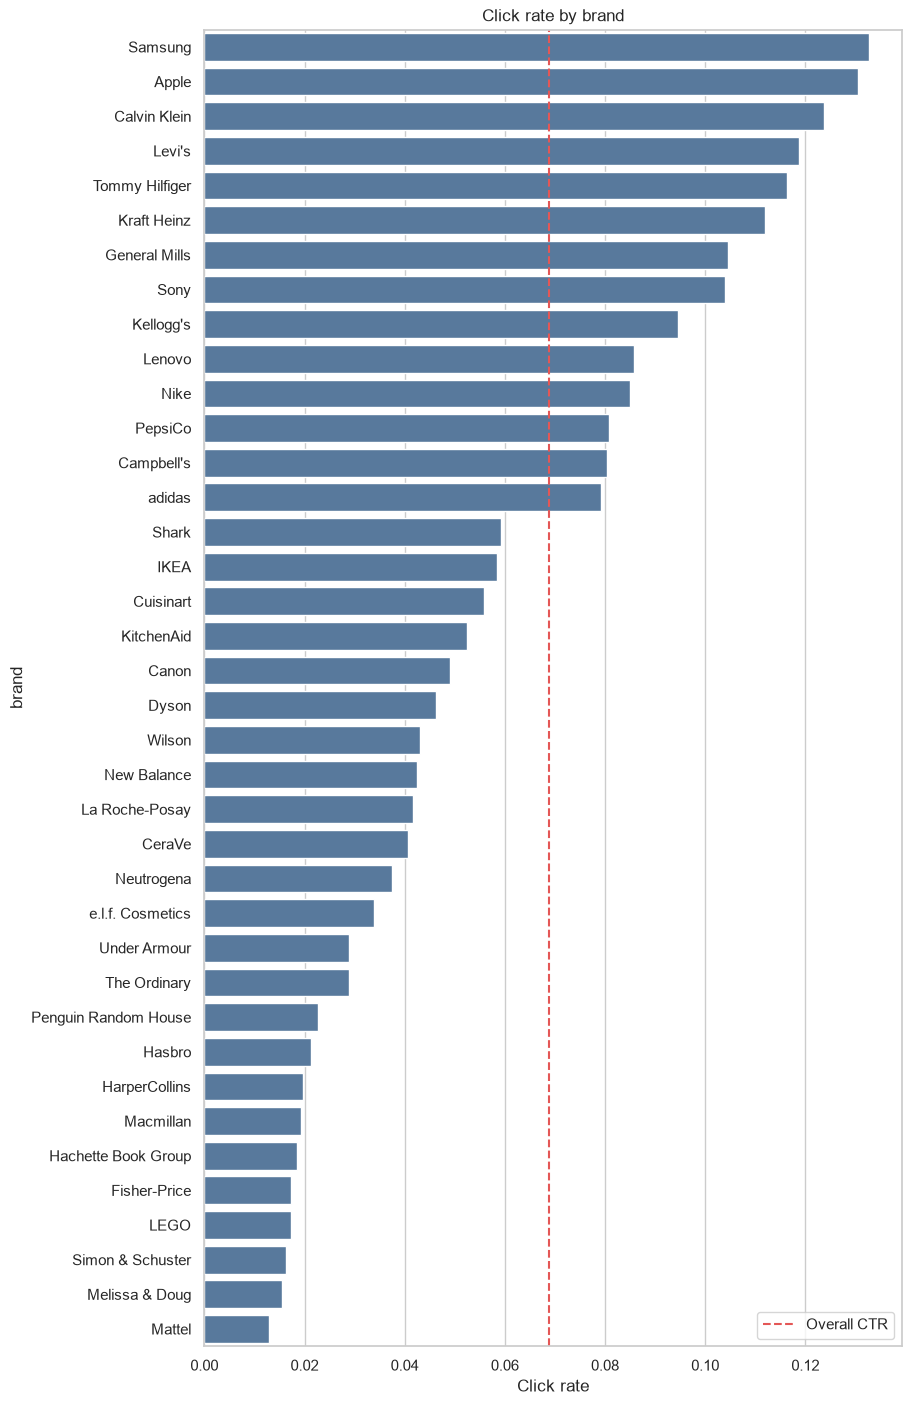

,impressions,clicks,click_rate
age_group,,,
18–24,78572,6715,0.085
55–64,15597,1065,0.068
25–34,140469,9514,0.068
45–54,67074,4456,0.066
65+,1849,121,0.065
35–44,146439,9116,0.062


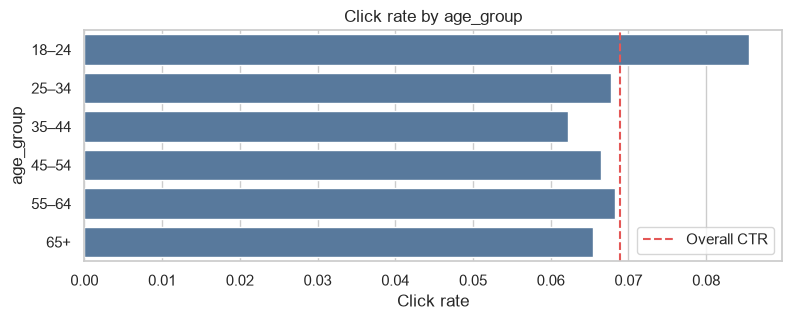

In [7]:
segment_summaries = {}
for column in ["gender", "loyalty_tier", "category", "brand"]:
    display(Markdown(f"### {column}"))
    minimum = 500 if column == "brand" else 1
    segment_summaries[column] = plot_group_ctr(df, column, min_rows=minimum)

df["age_group"] = pd.cut(
    df["age"], bins=[0, 24, 34, 44, 54, 64, float("inf")],
    labels=["18–24", "25–34", "35–44", "45–54", "55–64", "65+"]
)
age_summary = plot_group_ctr(df, "age_group")

## Numeric feature distributions and outliers

,count,mean,std,min,1%,25%,50%,75%,99%,max
age,"450,000.000",35.186,10.424,18.000,18.000,28.000,35.000,42.000,61.000,70.000
price_usd,"450,000.000",128.309,261.507,6.490,8.490,21.950,46.990,111.990,"1,612.990","2,064.950"
discount_pct,"450,000.000",8.236,5.381,0.000,0.000,4.000,7.000,12.000,23.000,30.000
avg_rating,"450,000.000",4.102,0.445,2.700,3.000,3.800,4.100,4.400,5.000,5.000
review_count,"450,000.000",179.206,183.510,5.000,14.000,67.000,124.000,215.000,894.000,"1,944.000"
slot_position,"450,000.000",2.649,1.532,1.000,1.000,1.000,2.000,4.000,6.000,6.000


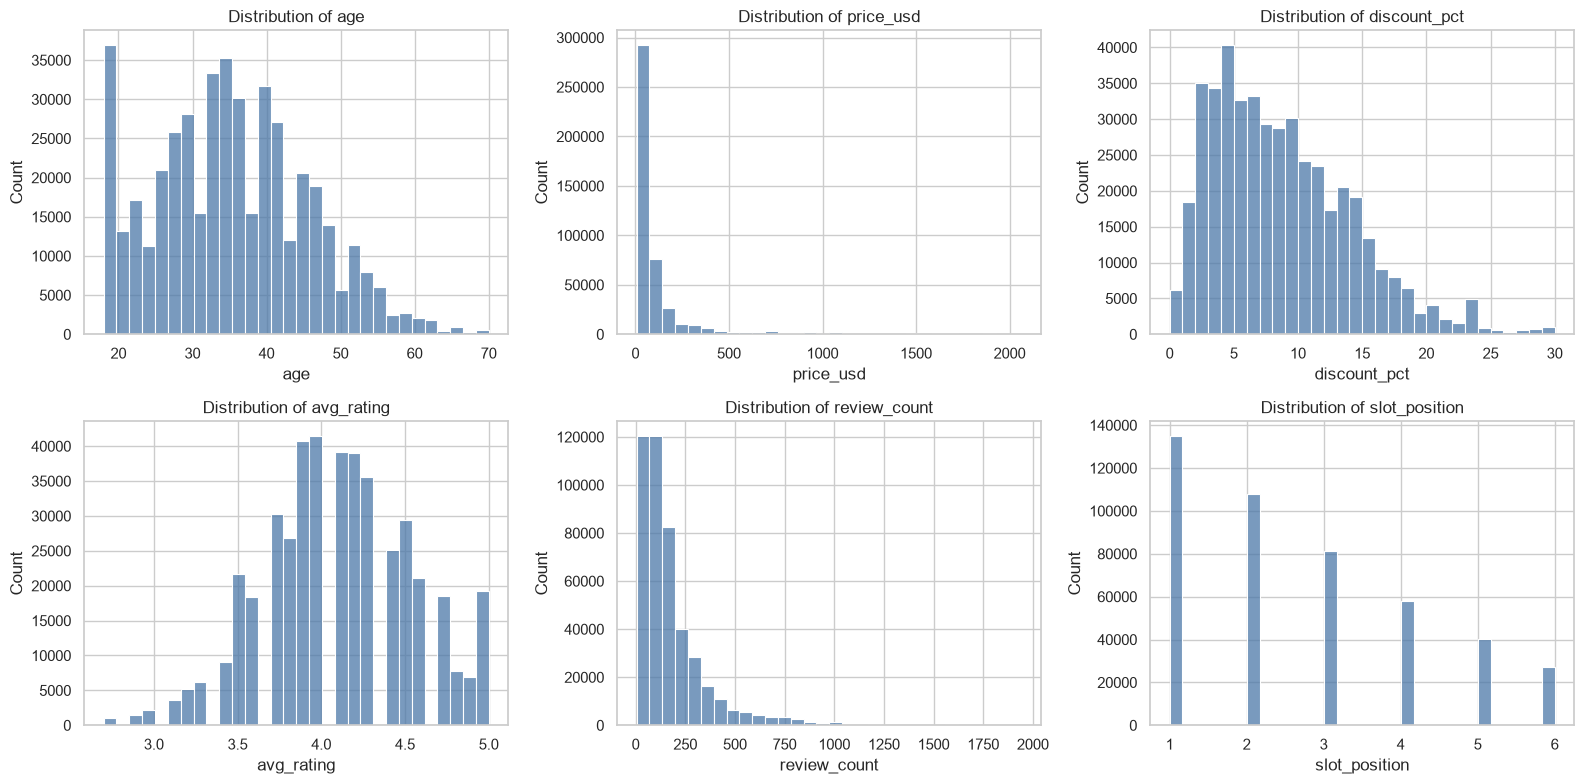

In [8]:
numeric_features = ["age", "price_usd", "discount_pct", "avg_rating", "review_count", "slot_position"]
display(df[numeric_features].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for column, ax in zip(numeric_features, axes.flat):
    sns.histplot(data=df, x=column, bins=30, ax=ax, color="#4C78A8")
    ax.set_title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

## Numeric relationships with clicks

,correlation_with_clicked
clicked,1.000
avg_rating,0.101
hour_of_day,0.014
discount_pct,0.012
review_count,0.008
price_usd,-0.023
age,-0.024
slot_position,-0.087


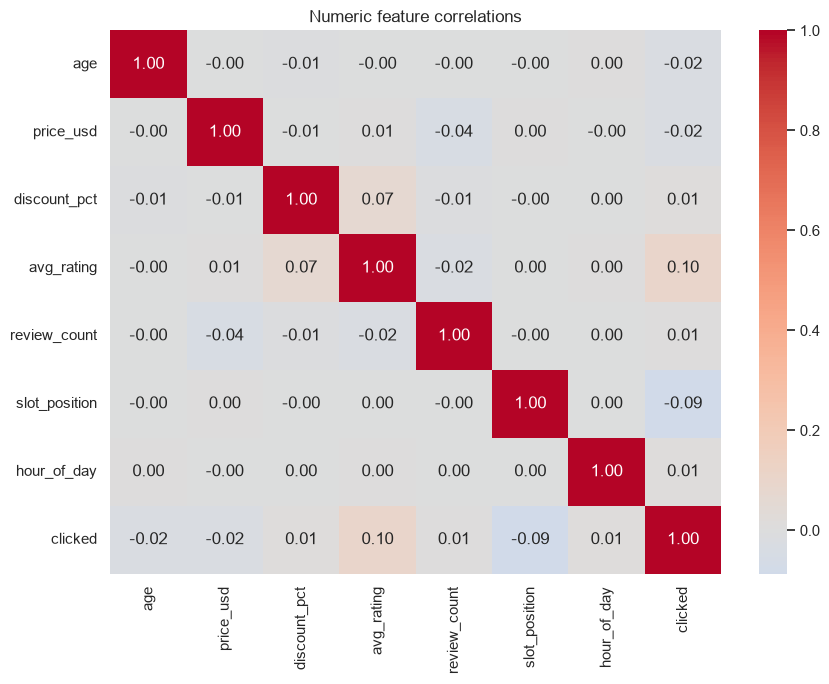

In [9]:
correlation_columns = numeric_features + ["hour_of_day", "clicked"]
correlations = df[correlation_columns].corr(numeric_only=True)
display(correlations["clicked"].sort_values(ascending=False).to_frame("correlation_with_clicked"))

plt.figure(figsize=(9, 7))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric feature correlations")
plt.tight_layout()
plt.show()

## Daily volume and click-rate stability

,impressions,clicks,click_rate
count,180.000,180.000,180.000
mean,"2,500.000",172.150,0.069
std,47.396,12.531,0.005
min,"2,388.000",138.000,0.055
25%,"2,466.000",164.750,0.066
50%,"2,494.500",173.000,0.069
75%,"2,533.250",181.000,0.072
max,"2,641.000",198.000,0.081


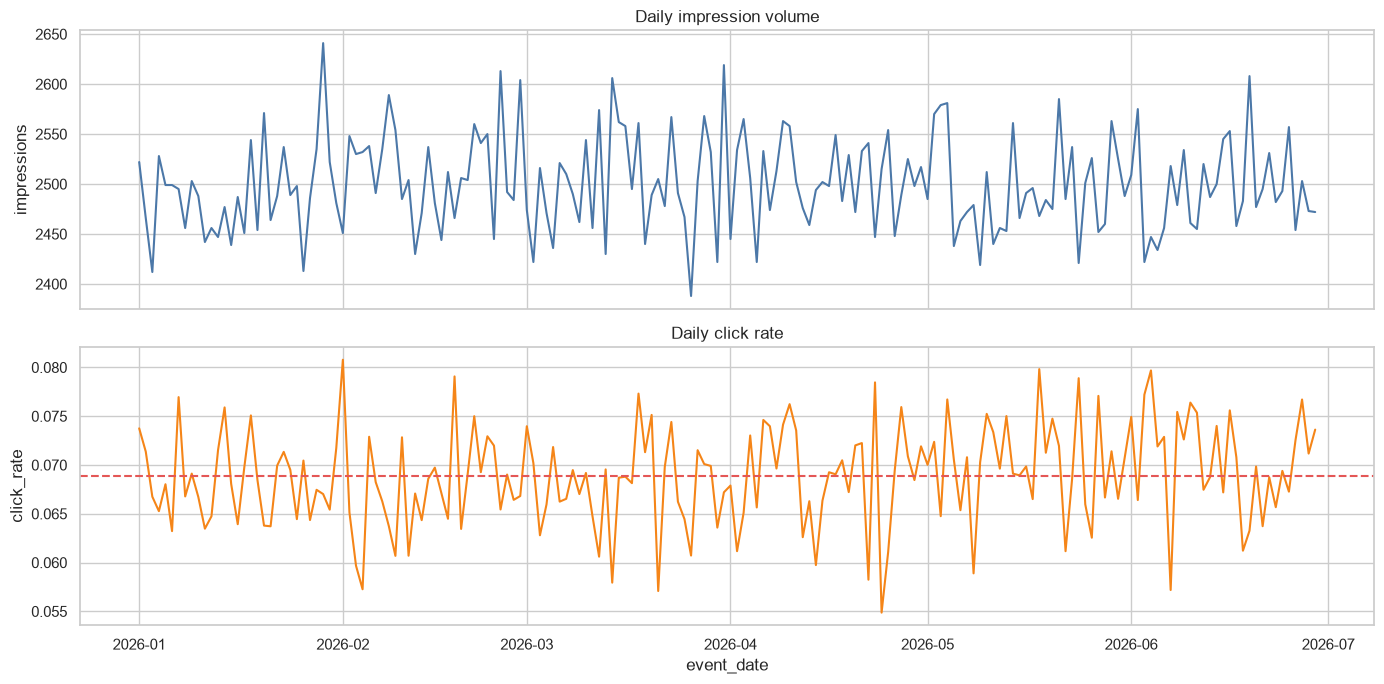

In [10]:
daily = (
    df.assign(event_date=df["event_ts"].dt.date)
    .groupby("event_date")["clicked"]
    .agg(impressions="size", clicks="sum", click_rate="mean")
    .reset_index()
)
display(daily.describe())

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
sns.lineplot(data=daily, x="event_date", y="impressions", ax=axes[0], color="#4C78A8")
axes[0].set_title("Daily impression volume")
sns.lineplot(data=daily, x="event_date", y="click_rate", ax=axes[1], color="#F58518")
axes[1].axhline(df["clicked"].mean(), color="#E45756", linestyle="--")
axes[1].set_title("Daily click rate")
plt.tight_layout()
plt.show()

## Quick recap

In [11]:
overall_ctr = df["clicked"].mean()
best_page = context_summaries["page_type"].index[0]
best_page_ctr = context_summaries["page_type"].iloc[0]["click_rate"]
best_hour = int(hourly.loc[hourly["click_rate"].idxmax(), "hour_of_day"])
best_hour_ctr = hourly["click_rate"].max()
best_category = segment_summaries["category"].index[0]
best_category_ctr = segment_summaries["category"].iloc[0]["click_rate"]
missing_total = int(df.isna().sum().sum())

display(Markdown(f"""
### What we learned

- The joined data has **{len(df):,} impressions** and **{df.shape[1]} columns**.
- The overall click rate is **{overall_ctr:.2%}**.
- **{best_page}** has the highest page-type click rate at **{best_page_ctr:.2%}**.
- Hour **{best_hour}:00** has the highest hourly click rate at **{best_hour_ctr:.2%}**.
- **{best_category}** has the highest category click rate at **{best_category_ctr:.2%}**.
- The joined data contains **{missing_total:,} missing values**. These need attention during preprocessing.
- Group click rates are useful clues, but small groups can look unusually strong by chance. Always check impression counts.
- The next step is preprocessing: split the data by time, handle missing values, encode categories, and avoid using future information.
"""))


### What we learned

- The joined data has **450,000 impressions** and **23 columns**.
- The overall click rate is **6.89%**.
- **product_detail** has the highest page-type click rate at **8.40%**.
- Hour **19:00** has the highest hourly click rate at **7.89%**.
- **Fashion** has the highest category click rate at **11.85%**.
- The joined data contains **0 missing values**. These need attention during preprocessing.
- Group click rates are useful clues, but small groups can look unusually strong by chance. Always check impression counts.
- The next step is preprocessing: split the data by time, handle missing values, encode categories, and avoid using future information.
